# Tradutor de Libras em Tempo Real: Alfabeto Manual via Landmarks

**Disciplina:** Tópicos Especiais em Matemática Aplicada, Visão Computacional com Deep Learning (UnB, FCTE)
**Professor:** Vinicius Rispoli. **Entrega:** 17/07/2026.

Prova de conceito (POC) de um tradutor do alfabeto manual de Libras em tempo real,
estruturada como um **estudo de ablação**: um classificador estático (MLP) e um
classificador temporal (Transformer encoder) são comparados nos regimes em que cada um
é a ferramenta adequada, isto é, letras paradas contra letras definidas por movimento.

Este notebook é autocontido: contém a aplicação completa, da aquisição de dados ao
sistema de inferência ao vivo, com todo o código, as justificativas de cada decisão
e os resultados. Organização: 1. Introdução, 2. Setup, 3. Métodos (com o código de
cada etapa), 4. Treino, 5. Resultados, 6. Inferência ao vivo, 7. Conclusão, 8. Referências.


## 1. Introdução

### 1.1 Problema e motivação

A Língua Brasileira de Sinais (Libras) é a segunda língua oficial do Brasil, mas a
barreira de comunicação entre surdos sinalizantes e ouvintes não sinalizantes permanece
no cotidiano. Um tradutor automático em tempo real, mesmo restrito ao alfabeto manual
(soletração de nomes, endereços e palavras fora do vocabulário), é um bloco fundamental
de acessibilidade.

### 1.2 Restrição de projeto e estratégia

O edital da disciplina proíbe abordagens exclusivamente de classificação de imagens
(por exemplo, uma CNN sobre pixels). Essa restrição motivou a estratégia central do
trabalho, o **isolamento geométrico via landmarks**: em vez de aprender sobre pixels,
extraímos as coordenadas 3D de 21 pontos anatômicos da mão com o MediaPipe Hand
Landmarker [1] e classificamos apenas essa geometria. As vantagens são decisivas para
uma POC em tempo real:

1. **Dimensionalidade**: 63 valores por frame contra cerca de 150 mil pixels. Os modelos
   ficam pequenos, treináveis em CPU, com inferência a cerca de 30 fps sem GPU.
2. **Invariância a aparência**: fundo, iluminação, tom de pele e câmera são eliminados
   pelo detector; o classificador vê apenas a forma da mão.
3. **Separação de responsabilidades**: a percepção (problema difícil, resolvido por um
   modelo pré-treinado em larga escala) fica no MediaPipe; nosso aprendizado se concentra
   no mapeamento da geometria para o símbolo.

### 1.3 Hipótese e desenho experimental (estudo de ablação)

O alfabeto manual de Libras tem duas naturezas de sinal:

* **Letras estáticas** (21 classes): a informação está na configuração da mão em um
  instante.
* **Letras dinâmicas** (6 classes: **h, j, k, x, y, z**): a informação está na
  trajetória. Um snapshot é ambíguo: o "j" é um "i" que se move.

**Hipótese:** um classificador estático sobre um único frame é suficiente (e ótimo) para
o primeiro grupo, mas estruturalmente incapaz no segundo, que exige um modelo com acesso
à dimensão temporal. O estudo de ablação compara:

| Modelo | Entrada | Regime alvo |
|---|---|---|
| MLP (baseline) | 1 frame (86 features) | letras estáticas |
| Transformer encoder | janela de 30 frames (30 x 86) | letras dinâmicas |

### 1.4 Escopo

A POC cobre o alfabeto completo (27 classes) com dois modelos especializados operando em
uma interface ao vivo com alternância por tecla. Fases anteriores do projeto exploraram
vocabulário de palavras (dataset MINDS-Libras [5]) e um modelo unificado de 79 classes;
a configuração final reverteu para modelos especialistas por precisão: o MLP
especializado atinge F1 macro 0.9947 nas letras estáticas contra 0.9839 do modelo
unificado, e as letras dinâmicas sustentam F1 igual a 1.00 (detalhes na seção 5.3).
Sinais de duas mãos e sinais que dependem do ângulo Z da palma estão fora do escopo.


## 2. Setup do ambiente e dados

O notebook roda no Google Colab ou localmente.

**No Colab**: suba para o seu Google Drive, em `MyDrive/libras/`, o arquivo
`libras_dataset_drive.zip` (cerca de 12 MB). Ele pode ser gerado pela célula da seção
2.1 a partir de uma pasta `data/` local e contém os quatro conjuntos de dados já
processados em tensores `.npy` de shape `(30, 66)` (formato explicado na seção 3.4):

```
processed/alphabet/   3840 amostras, 15 classes  (imagens do Brazilian Alphabet [4])
raw/                   320 amostras,  8 classes  (capturas próprias na webcam alvo)
luiz_split/static/    1000 amostras, 20 classes  (capturas da equipe, letras estáticas)
luiz_split/dynamic/    300 amostras,  6 classes  (capturas da equipe, letras dinâmicas)
```

**Localmente**: basta uma pasta `data/` ao lado deste notebook (ou no diretório pai)
com a mesma estrutura acima.


In [1]:
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    %pip -q install mediapipe
    os.makedirs("/content/libras", exist_ok=True)
    %cd /content/libras
    !unzip -qo "/content/drive/MyDrive/libras/libras_dataset_drive.zip" -d data/
    ROOT = Path("/content/libras")
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    os.chdir(ROOT)

DATA = ROOT / "data"
ARTEFATOS = ROOT / "artifacts"      # onde este notebook salva pesos e logs
ARTEFATOS.mkdir(exist_ok=True)
print(f"Raiz de trabalho: {ROOT}")
assert (DATA / "processed" / "alphabet").is_dir(), "pasta data/ nao encontrada (ver secao 2)"


Raiz de trabalho: /home/diogo/Coding/Faculdade/TEMA/libras-cv-translator


In [2]:
import json
import math
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset, Subset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cpu


### 2.1 Geração do pacote de dados para o Drive (opcional)

A célula abaixo compacta a pasta `data/` local no arquivo `libras_dataset_drive.zip`,
resolvendo links simbólicos e incluindo apenas os `.npy`. Rode uma vez na máquina que
tem os dados e suba o zip para `MyDrive/libras/` no Google Drive.


In [3]:
GERAR_ZIP_DRIVE = False

if GERAR_ZIP_DRIVE:
    import zipfile
    alvo = DATA / "libras_dataset_drive.zip"
    fontes = ["processed/alphabet", "raw", "luiz_split/static", "luiz_split/dynamic"]
    with zipfile.ZipFile(alvo, "w", zipfile.ZIP_DEFLATED) as z:
        for fonte in fontes:
            base = DATA / fonte
            # os.walk segue symlinks de diretorio com followlinks=True
            for dirpath, _, files in os.walk(base, followlinks=True):
                for f in sorted(files):
                    if f.endswith(".npy"):
                        p = Path(dirpath) / f
                        z.write(p, arcname=str(Path(fonte) / Path(dirpath).relative_to(base) / f))
    print(f"Gerado: {alvo} ({alvo.stat().st_size/1e6:.1f} MB)")


## 3. Métodos

### 3.1 Pipeline geral

```
webcam -> MediaPipe Hand Landmarker [1] -> 21 landmarks 3D (63 valores)
       -> normalizacao (translacao + escala)
       -> vetor de features por frame: 66 = 63 + delta do pulso (3)
       -> expansao geometrica em memoria: 86 = 66 + 20 (secao 3.3)
       -> MLP (frame central)  ou  Transformer (janela de 30 frames)
       -> guardrails temporais (suavizacao + consenso) -> simbolo
```

O mesmo pipeline processa todas as fontes de dados (webcam ao vivo, imagens de dataset
externo), garantindo que treino e inferência vejam exatamente a mesma distribuição de
features. As constantes abaixo definem o contrato de dados de ponta a ponta.


In [4]:
# Constantes do pipeline (contrato de dados)
FRAMES = 30                    # janela temporal: 1 segundo a ~30 fps
COORDS = 21 * 3                # 21 landmarks x (x, y, z) = 63
DELTA = 3                      # deslocamento (dx, dy, dz) do pulso entre frames
FEATURE_DIM = COORDS + DELTA   # 66 valores por frame, formato persistido em disco
GEOMETRIC_DIM = 20             # features geometricas calculadas em memoria
FEATURE_DIM_EXTENDED = FEATURE_DIM + GEOMETRIC_DIM  # 86, o que os modelos consomem
STATIC_FRAME_IDX = FRAMES // 2 # frame central da janela, usado pelo MLP

WRIST_IDX = 0                  # pulso: origem da translacao
SCALE_IDX = 9                  # base do dedo medio: referencia de escala
FINGERTIP_INDICES_ORDERED = (4, 8, 12, 16, 20)   # pontas: polegar ... minimo
MCP_INDICES_ORDERED = (2, 5, 9, 13, 17)          # base de cada dedo (flexao)

# Conexoes do esqueleto da mao (para desenho na inferencia ao vivo)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
    (5, 9), (9, 13), (13, 17),
]


### 3.2 Aquisição de dados

Quatro fontes alimentam o projeto, todas convergindo para o mesmo formato em disco:

| Fonte | Tipo | Classes | Amostras | Papel |
|---|---|---|---|---|
| Brazilian Alphabet [4] | imagens estáticas de estúdio | 15 | 3840 | volume para o MLP |
| Capturas próprias | webcam alvo | 8 | 320 | domínio alvo |
| Equipe, letras estáticas | webcam | 20 | 1000 | volume e diversidade |
| Equipe, letras dinâmicas | webcam, vídeo | 6 | 300 | treino do Transformer |

**Domain shift.** O Brazilian Alphabet é gravado em estúdio; a inferência acontece em
webcams domésticas. A experiência do projeto (três tentativas de resolver apenas com
engenharia de features e augmentation) mostrou que esse deslocamento de domínio só fecha
com dados do próprio domínio alvo. Por isso as capturas próprias entram no treino e
nunca são subamostradas. Augmentation reduz o problema, mas não o substitui.

A célula abaixo define as funções de aquisição: o pré-processamento de imagens externas
e a captura por webcam (estática, em rajada de fotos, e dinâmica, em janelas de 30
frames). São as ferramentas que geraram os `.npy` usados no treino; a captura exige
webcam e interface gráfica, então fica desligada por padrão.


In [5]:
# Aquisicao: MediaPipe -> landmarks -> .npy (30, 66)
# As funcoes de features usadas aqui estao definidas na secao 3.3;
# esta celula so define utilitarios, nada e executado por padrao.

MEDIAPIPE_TASK = "models/hand_landmarker.task"  # baixado na celula abaixo, se ausente

def baixar_hand_landmarker(destino=MEDIAPIPE_TASK):
    """Baixa o modelo de deteccao de maos do MediaPipe (uma vez)."""
    import urllib.request
    p = Path(destino)
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        url = ("https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
               "hand_landmarker/float16/latest/hand_landmarker.task")
        urllib.request.urlretrieve(url, p)
    return str(p)


def criar_landmarker(modo_video=False):
    """Instancia o detector. IMAGE para fotos; VIDEO mantem tracking entre frames,
    essencial para nao perder a mao em movimento rapido."""
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    from mediapipe.tasks.python.vision import RunningMode
    options = mp_vision.HandLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=baixar_hand_landmarker()),
        running_mode=RunningMode.VIDEO if modo_video else RunningMode.IMAGE,
        num_hands=1,
        min_hand_detection_confidence=0.6 if modo_video else 0.5,
        min_hand_presence_confidence=0.4,
        min_tracking_confidence=0.4,
    )
    return mp_vision.HandLandmarker.create_from_options(options)


def preprocessar_imagens(input_dir, output_dir):
    """Converte um dataset de imagens (subpastas por classe) em tensores (30, 66).

    Cada imagem vira um tensor com o frame replicado 30 vezes e delta zero
    (sinal estatico, ver secao 3.4). Imagens sem mao detectada sao descartadas.
    """
    import cv2
    import mediapipe as mp
    landmarker = criar_landmarker(modo_video=False)
    input_dir, output_dir = Path(input_dir), Path(output_dir)
    descartadas = 0
    for cls_dir in sorted(p for p in input_dir.iterdir() if p.is_dir()):
        out = output_dir / cls_dir.name.lower()
        out.mkdir(parents=True, exist_ok=True)
        idx = 0
        for img_path in sorted(cls_dir.iterdir()):
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp"}:
                continue
            img = cv2.imread(str(img_path))
            if img is None:
                descartadas += 1
                continue
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                              data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            result = landmarker.detect(mp_img)
            if not result.hand_landmarks:
                descartadas += 1
                continue
            raw = extract_landmarks(result.hand_landmarks[0])
            normalized, wrist_raw = normalize_landmarks(raw)
            vec = build_feature_vector(normalized, wrist_raw, wrist_raw)  # delta 0
            tensor = np.tile(vec, (FRAMES, 1)).astype(np.float32)         # (30, 66)
            np.save(out / f"{idx}.npy", tensor)
            idx += 1
        print(f"  {cls_dir.name.lower()}: {idx} amostras")
    landmarker.close()
    print(f"Descartadas (sem mao ou leitura invalida): {descartadas}")


def capturar_webcam(sinal, n_amostras=40, dinamico=False, destino=None):
    """Captura amostras pela webcam (exige interface grafica; nao roda no Colab).

    Estatico: barra de espaco tira uma foto, que vira (30, 66) com frame replicado.
    Dinamico: barra de espaco grava 30 frames consecutivos com o delta do pulso
    calculado entre frames (a trajetoria do movimento e o proprio sinal).
    Tecla q encerra.
    """
    import cv2
    import mediapipe as mp
    destino = Path(destino or (DATA / ("raw/dynamic" if dinamico else "raw") / sinal.lower()))
    destino.mkdir(parents=True, exist_ok=True)
    idx = len(list(destino.glob("*.npy")))
    landmarker = criar_landmarker(modo_video=True)
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    t0 = time.monotonic()
    gravando, buffer, prev_wrist = False, [], None
    while idx < n_amostras:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.flip(frame, 1)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                          data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        result = landmarker.detect_for_video(mp_img, int((time.monotonic() - t0) * 1000))
        vec = None
        if result.hand_landmarks:
            raw = extract_landmarks(result.hand_landmarks[0])
            normalized, wrist_raw = normalize_landmarks(raw)
            if prev_wrist is None or not gravando:
                prev_wrist = wrist_raw.copy()
            vec = build_feature_vector(normalized, wrist_raw, prev_wrist)
            prev_wrist = wrist_raw.copy()
        if gravando and vec is not None:
            buffer.append(vec)
            if len(buffer) == FRAMES:
                np.save(destino / f"{idx}.npy", np.stack(buffer).astype(np.float32))
                idx += 1
                gravando, buffer = False, []
        cv2.putText(frame, f"{sinal.upper()} {idx}/{n_amostras}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        cv2.imshow("captura", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        if key == ord(" ") and vec is not None:
            if dinamico:
                gravando, buffer = True, []
            else:
                tensor = np.tile(np.concatenate([vec[:63], np.zeros(3, np.float32)]),
                                 (FRAMES, 1)).astype(np.float32)
                np.save(destino / f"{idx}.npy", tensor)
                idx += 1
    cap.release()
    cv2.destroyAllWindows()
    landmarker.close()
    print(f"Total em {destino}: {idx} amostras")

print("Funcoes de aquisicao definidas (execucao manual, quando necessario).")


Funcoes de aquisicao definidas (execucao manual, quando necessario).


### 3.3 Normalização e engenharia de features

O vetor cru do MediaPipe depende de onde a mão está no quadro e do tamanho aparente
dela. Duas transformações clássicas removem essas variâncias espúrias:

1. **Translação**: o pulso (landmark 0) vira a origem, o que dá invariância à posição.
2. **Escala**: divisão pela distância do pulso à base do dedo médio (landmark 9),
   o que dá invariância à distância da câmera.

A cada frame concatenamos o deslocamento `(dx, dy, dz)` do pulso em relação ao frame
anterior: é a assinatura de movimento global da mão e o discriminante bruto entre sinais
estáticos (delta próximo de zero) e dinâmicos.

**Features geométricas (66 para 86).** Rotações da mão no plano da câmera ainda mudam
todas as coordenadas. Em vez de tentar normalizar rotação (frágil com landmarks 3D
ruidosos), adicionamos 20 medidas invariantes a rotação, calculadas em memória no
carregamento (nunca persistidas em disco):

* 10 distâncias par a par entre as 5 pontas de dedos;
* 5 distâncias de cada ponta de dedo ao pulso;
* 5 métricas de flexão (ponta à base do respectivo dedo).

Distâncias euclidianas são invariantes a rotação e, após a normalização de escala,
também a zoom. É a mesma família dos descritores geométricos clássicos de forma da mão.


In [6]:
def extract_landmarks(landmarks):
    """Converte os 21 landmarks do MediaPipe em array (63,): [x0,y0,z0, x1,y1,z1, ...]."""
    coords = []
    for lm in landmarks:
        coords.extend([lm.x, lm.y, lm.z])
    return np.array(coords, dtype=np.float32)


def normalize_landmarks(raw):
    """Normaliza landmarks e devolve tambem o pulso bruto (para o calculo do delta).

    Retorna:
        normalized: (63,) coordenadas normalizadas (translacao + escala)
        wrist_raw:  (3,)  posicao bruta do pulso antes da normalizacao
    """
    points = raw.reshape(21, 3)
    wrist_raw = points[WRIST_IDX].copy()
    points = points - wrist_raw                      # translacao: pulso na origem
    scale = np.linalg.norm(points[SCALE_IDX])        # escala: pulso ate a base do medio
    if scale > 1e-6:
        points = points / scale
    return points.flatten(), wrist_raw


def build_feature_vector(normalized, wrist_raw, prev_wrist):
    """(66,) = [63 coordenadas normalizadas | dx, dy, dz do pulso].
    No primeiro frame de uma amostra, prev_wrist == wrist_raw, logo delta = 0."""
    delta = wrist_raw - prev_wrist
    return np.concatenate([normalized, delta])


_TIP_PAIRS = [(i, j) for i in range(5) for j in range(i + 1, 5)]  # 10 pares

def build_geometric_features(points):
    """20 features invariantes a rotacao, derivadas dos landmarks normalizados (21, 3).

    [ 0:10] distancias par a par entre as 5 pontas de dedos (discrimina V, U, D, R)
    [10:15] distancias ponta de dedo ao pulso (mao aberta contra fechada)
    [15:20] distancia ponta a base do dedo (flexao de cada dedo)
    """
    tips = points[list(FINGERTIP_INDICES_ORDERED)]
    mcps = points[list(MCP_INDICES_ORDERED)]
    wrist = points[WRIST_IDX]
    tip_pairs = np.array([np.linalg.norm(tips[i] - tips[j]) for i, j in _TIP_PAIRS],
                         dtype=np.float32)
    tips_to_wrist = np.linalg.norm(tips - wrist, axis=1).astype(np.float32)
    flexions = np.linalg.norm(tips - mcps, axis=1).astype(np.float32)
    return np.concatenate([tip_pairs, tips_to_wrist, flexions])


### 3.4 Representação temporal canônica: tensor (30, 66)

Toda amostra em disco é um tensor `(30, 66) float32`: 30 frames (cerca de 1 segundo a
30 fps) por 66 features. A decisão chave é usar um único formato para os dois regimes:

* **Sinais dinâmicos**: 30 frames reais da trajetória, com delta do pulso entre frames.
* **Sinais estáticos**: o frame único é replicado 30 vezes, com delta igual a zero.

Um contrato único de dados simplifica o carregamento, a validação de integridade e
mantém os dois regimes intercambiáveis no mesmo pipeline. O MLP consome apenas o frame
central da janela (índice 15); o Transformer consome a janela completa.

### 3.5 Augmentation de landmarks

Augmentation clássica de imagem não se aplica: não há imagem. As perturbações agem
diretamente sobre os 21 landmarks `(21, 3)` normalizados, simulando as variações que a
webcam alvo produz [6]:

| Perturbação | Faixa | Simula |
|---|---|---|
| Rotação 3D | 25 graus | mão inclinada |
| Escala | 15 por cento | perto ou longe da câmera |
| Translação | 0.08 | enquadramento |
| Ruído gaussiano | desvio 0.015 | jitter do detector |

Duas decisões importantes:

1. **Coerência temporal**: para sequências, sorteia-se uma única transformação por
   amostra, aplicada aos 30 frames. Perturbar cada frame de forma independente
   destruiria a trajetória, que é o próprio sinal.
2. **Oversampling 4x**: cada amostra passa 4 vezes por época, cada vez com augmentation
   diferente. Multiplica a diversidade efetiva sem inflar o disco. As faixas fortes são
   deliberadas: o dataset é pequeno e o domínio alvo é hostil.

Augmentation é aplicada apenas no split de treino; a validação vê dados limpos.


In [7]:
def _rotation_matrix_3d(rx, ry, rz):
    cx, sx = np.cos(rx), np.sin(rx)
    cy, sy = np.cos(ry), np.sin(ry)
    cz, sz = np.cos(rz), np.sin(rz)
    Rx = np.array([[1, 0, 0], [0, cx, -sx], [0, sx, cx]], dtype=np.float32)
    Ry = np.array([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]], dtype=np.float32)
    Rz = np.array([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]], dtype=np.float32)
    return Rz @ Ry @ Rx


def sample_augment_params(rng, rot_range_deg=15.0, scale_range=0.10,
                          translation_range=0.05, noise_std=0.01):
    """Sorteia uma vez os parametros de rotacao, escala e translacao.
    Para sequencias, o sorteio e por amostra: os 30 frames recebem a mesma
    transformacao (coerencia temporal). O ruido e aplicado por frame."""
    angles = np.deg2rad(rng.uniform(-rot_range_deg, rot_range_deg, size=3))
    R = _rotation_matrix_3d(float(angles[0]), float(angles[1]), float(angles[2]))
    scale = float(1.0 + rng.uniform(-scale_range, scale_range))
    trans = rng.uniform(-translation_range, translation_range, size=3).astype(np.float32)
    return {"R": R, "scale": scale, "trans": trans, "noise_std": float(noise_std)}


def apply_augment_params(points, params, rng):
    """Aplica os parametros a um frame (21, 3): rotacao, escala, translacao, ruido."""
    pts = points @ params["R"].T
    pts = pts * params["scale"]
    pts = pts + params["trans"]
    pts = pts + rng.normal(0, params["noise_std"], size=pts.shape).astype(np.float32)
    return pts.astype(np.float32)


def expand_frame_for_model(frame, augment=False, rng=None, aug_kwargs=None):
    """Ponto unico entre o (66,) do disco e o (86,) que o MLP consome.
    O delta do pulso nao sofre augmentation (semantica temporal bruta)."""
    coords = frame[:63].reshape(21, 3).astype(np.float32)
    delta = frame[63:66].astype(np.float32)
    if augment:
        rng = rng or np.random.default_rng()
        params = sample_augment_params(rng, **(aug_kwargs or {}))
        coords = apply_augment_params(coords, params, rng)
    geom = build_geometric_features(coords)
    return np.concatenate([coords.flatten(), delta, geom]).astype(np.float32)


def expand_sequence_for_model(tensor, augment=False, rng=None, aug_kwargs=None):
    """Analogo para a janela completa (30, 66) -> (30, 86), com UM sorteio de
    augmentation aplicado a todos os frames (preserva a trajetoria)."""
    rng = rng or np.random.default_rng()
    aug_params = sample_augment_params(rng, **(aug_kwargs or {})) if augment else None
    T = tensor.shape[0]
    out = np.empty((T, FEATURE_DIM_EXTENDED), dtype=np.float32)
    for t in range(T):
        coords = tensor[t, :63].reshape(21, 3).astype(np.float32)
        delta = tensor[t, 63:66].astype(np.float32)
        if aug_params is not None:
            coords = apply_augment_params(coords, aug_params, rng)
        geom = build_geometric_features(coords)
        out[t] = np.concatenate([coords.flatten(), delta, geom])
    return out


### 3.6 Dataset PyTorch e split estratificado

O loader varre um ou mais diretórios raiz (a união das subpastas define as classes),
valida o shape de cada tensor e faz a expansão 66 para 86 em memória. O split de
validação é estratificado por classe (classes raras presentes nos dois lados) e feito
sobre os arquivos únicos, antes do oversampling: as visitas repetidas de uma amostra de
treino nunca vazam para a validação, e a validação usa um dataset gêmeo sem augmentation.


In [8]:
def build_label_map(root_dirs):
    """Uniao das subpastas de todos os roots -> {classe: indice}, ordem lexicografica."""
    labels = set()
    for root in root_dirs:
        root = Path(root)
        if not root.is_dir():
            raise FileNotFoundError(f"Diretorio de dados nao existe: {root}")
        labels.update(p.name for p in root.iterdir() if p.is_dir())
    return {label: idx for idx, label in enumerate(sorted(labels))}


class LibrasDataset(Dataset):
    """Dataset de tensores (30, 66) em .npy, com dois modos de leitura:
    'static'   -> (86,) do frame central (MLP)
    'sequence' -> (30, 86) da janela completa (Transformer)
    """

    def __init__(self, root_dirs, mode="static", label_map=None, augment=False,
                 aug_kwargs=None, rng_seed=None, oversample_factor=1):
        self.root_dirs = [Path(r) for r in root_dirs]
        self.mode = mode
        self.augment = augment
        self.aug_kwargs = aug_kwargs or {}
        self._rng = np.random.default_rng(rng_seed)
        self.label_map = label_map or build_label_map(self.root_dirs)
        # Oversample so faz sentido com augment: replica logicamente o dataset
        # e cada visita gera uma augmentation diferente.
        self.oversample_factor = oversample_factor if augment else 1

        self.samples = []
        for label, idx in self.label_map.items():
            for root in self.root_dirs:
                class_dir = root / label
                if class_dir.is_dir():
                    for npy in sorted(class_dir.glob("*.npy")):
                        self.samples.append((npy, idx))
        if not self.samples:
            raise ValueError(f"Nenhum .npy encontrado sob {self.root_dirs}")

    def __len__(self):
        return len(self.samples) * self.oversample_factor

    def __getitem__(self, idx):
        path, label = self.samples[idx % len(self.samples)]
        tensor = np.load(path)
        if tensor.shape != (FRAMES, FEATURE_DIM):
            raise ValueError(f"Shape inesperado em {path}: {tensor.shape}")
        if self.mode == "static":
            data = expand_frame_for_model(tensor[STATIC_FRAME_IDX], augment=self.augment,
                                          rng=self._rng, aug_kwargs=self.aug_kwargs)
        else:
            data = expand_sequence_for_model(tensor, augment=self.augment,
                                             rng=self._rng, aug_kwargs=self.aug_kwargs)
        return torch.from_numpy(data).float(), label

    @property
    def num_classes(self):
        return len(self.label_map)


def stratified_split(dataset, val_dataset, val_ratio=0.2, seed=SEED):
    """Split estratificado sobre os arquivos unicos; o treino expande as visitas
    do oversample e a validacao usa o dataset gemeo sem augmentation."""
    n_base = len(dataset.samples)
    base_targets = [label for _, label in dataset.samples]
    train_base, val_base = train_test_split(list(range(n_base)), test_size=val_ratio,
                                            stratify=base_targets, random_state=seed)
    factor = dataset.oversample_factor
    train_idx = [b + k * n_base for k in range(factor) for b in train_base]
    return Subset(dataset, train_idx), Subset(val_dataset, val_base)


### 3.7 Arquiteturas

**MLP estático (baseline).** `86 -> 256 -> 128 -> 64 -> 21`, com ReLU e dropout 0.2 [7].
Justificativa: com landmarks normalizados, a entrada já é um vetor de features de alto
nível, de baixa dimensão e sem estrutura espacial de grade; não há o que convoluir. Um
MLP é o aproximador adequado, treina em minutos de CPU e serve de baseline honesto para
a ablação. A capacidade (cerca de 60 mil parâmetros) é dimensionada para 21 classes bem
separáveis.

**Transformer temporal.** Para as letras dinâmicas:

```
(30, 86) -> Linear(86 -> 128) + positional encoding senoidal
         -> 3 x TransformerEncoderLayer (pre-LN, 4 heads, FFN 256, GELU, dropout 0.1)
         -> LayerNorm -> mean pooling temporal -> Linear(128 -> 6)
```

Justificativas de projeto:

* **Atenção contra recorrência**: a self-attention [2] dá a cada frame acesso direto a
  qualquer outro frame da janela (caminho de gradiente de comprimento constante entre
  posições) e paraleliza o treino em CPU. Com janela fixa de 30 frames, a principal
  vantagem de uma LSTM (comprimento variável) é irrelevante.
* **Positional encoding senoidal** [2]: injeta a ordem temporal sem parâmetros extras.
  Com dataset pequeno, embeddings posicionais aprendidos seriam capacidade a mais sem
  dados para sustentá-la.
* **Pre-LN** [3]: normalização antes da atenção estabiliza o treino sem warmup de taxa
  de aprendizado, o que importa num orçamento curto de CPU.
* **Mean pooling** na saída: para classificar a janela inteira, a média é um agregador
  simples e robusto; um token de classe adicionaria capacidade sem necessidade.


In [9]:
class MLPStatic(nn.Module):
    """MLP sobre um unico frame de features (86 dims). Saida: logits."""

    def __init__(self, num_classes, input_dim=FEATURE_DIM_EXTENDED,
                 hidden_dims=(256, 128, 64), dropout=0.2):
        super().__init__()
        self.config = {"name": "mlp_static", "input_dim": input_dim,
                       "hidden_dims": list(hidden_dims), "num_classes": num_classes,
                       "dropout": dropout}
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def _sinusoidal_positional_encoding(seq_len, d_model):
    """Positional encoding senoidal padrao [2], pre-computado: (1, seq_len, d_model)."""
    pos = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)
    div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32)
                    * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe.unsqueeze(0)


class TransformerTemporal(nn.Module):
    """Classificador temporal para as letras dinamicas (h, j, k, x, y, z).
    Entrada (B, 30, 86); saida: logits (B, num_classes)."""

    def __init__(self, num_classes, input_dim=FEATURE_DIM_EXTENDED, seq_len=FRAMES,
                 d_model=128, n_heads=4, n_layers=3, d_ff=256, dropout=0.1):
        super().__init__()
        self.config = {"name": "transformer_temporal", "num_classes": num_classes,
                       "input_dim": input_dim, "seq_len": seq_len, "d_model": d_model,
                       "n_heads": n_heads, "n_layers": n_layers, "d_ff": d_ff,
                       "dropout": dropout}
        self.input_proj = nn.Linear(input_dim, d_model)
        self.register_buffer("pos_enc", _sinusoidal_positional_encoding(seq_len, d_model),
                             persistent=False)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout,
            activation="gelu", batch_first=True,
            norm_first=True,  # pre-LN: mais estavel em treinos curtos [3]
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        h = self.input_proj(x) + self.pos_enc[:, : x.size(1)]
        h = self.encoder(h)
        h = self.norm(h)
        h = h.mean(dim=1)      # mean pooling temporal
        return self.head(h)


### 3.8 Otimização e protocolo de treino

| Item | Valor | Por que |
|---|---|---|
| Otimizador | Adam, lr 1e-3 [8] | robusto sem tuning fino; padrão para datasets pequenos |
| Weight decay | 1e-4 | regularização L2 leve contra overfit |
| Class weights | inverso da frequência | desbalanceamento (por exemplo, 31 amostras de "n" contra 563 de "b"); sem isso o modelo colapsa nas classes raras |
| Scheduler | ReduceLROnPlateau, fator 0.5, paciência 6, sobre o F1 macro de validação | a métrica de seleção é a métrica alvo, não a loss |
| Early stopping | paciência 20 épocas (máximo 150) | orçamento de CPU; evita treinar após o platô |
| Split | 80/20 estratificado, semente 42 | classes raras presentes na validação; reprodutibilidade |
| Métrica | F1 macro | com classes desbalanceadas, a acurácia esconde o colapso das raras; a média macro pesa todas igualmente |
| Checkpoint | melhor F1 macro de validação | o artefato final é o melhor modelo, não o último |

**Ablação de hiperparâmetros do Transformer**, feita na fase em que o modelo treinava
com 20 palavras do dataset MINDS-Libras [5] (288 amostras, o cenário mais difícil que a
arquitetura enfrentou no projeto):

| execução | d_model | camadas | dropout | F1 macro (validação) |
|---|---|---|---|---|
| 1 | 128 | 3 | 0.1 | 0.8474 |
| 2 | 128 | 2 | 0.2 | 0.8242 |

Reduzir capacidade e regularizar mais piorou a validação: a limitação era a diversidade
de dados, não overfit de arquitetura. A configuração da execução 1 foi mantida. Para 6
classes ela é folgada, e as curvas de validação (seção 5) confirmam a ausência de
overfit prejudicial.


In [10]:
HPARAMS = {
    "hidden_dims": [256, 128, 64],
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 64,
    "epochs": 150,
    "patience": 20,
    "val_ratio": 0.2,
    "class_weight": True,
    "lr_scheduler_factor": 0.5,
    "lr_scheduler_patience": 6,
    "lr_min": 1e-6,
    "augment": True,
    "augmentation": {
        "rot_range_deg": 25.0,
        "scale_range": 0.15,
        "translation_range": 0.08,
        "noise_std": 0.015,
    },
    "oversample_factor": 4,
    "seed": SEED,
    "transformer": {"d_model": 128, "n_heads": 4, "n_layers": 3, "d_ff": 256, "dropout": 0.1},
}


## 4. Treino

A função abaixo executa o protocolo completo da seção 3.8 para qualquer um dos dois
modelos: monta os datasets (treino com augmentation e oversampling, validação limpa),
faz o split estratificado, treina com early stopping e devolve o histórico e o
relatório final do melhor checkpoint. Os artefatos (pesos, mapa de classes,
configuração e log) são salvos na pasta `artifacts`.


In [11]:
def evaluate(model, loader, criterion, num_classes):
    model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        "loss": total_loss / len(y_true),
        "acc": float((y_true == y_pred).mean()),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "y_true": y_true, "y_pred": y_pred,
    }


def treinar(nome, roots, modo):
    """Treina um modelo ('mlp_static' ou 'transformer_temporal') e salva artefatos."""
    roots = [Path(r) for r in roots]
    label_map = build_label_map(roots)
    aug = HPARAMS["augmentation"]

    train_full = LibrasDataset(roots, mode=modo, label_map=label_map, augment=True,
                               aug_kwargs=aug, rng_seed=SEED,
                               oversample_factor=HPARAMS["oversample_factor"])
    val_full = LibrasDataset(roots, mode=modo, label_map=label_map, augment=False)
    train_sub, val_sub = stratified_split(train_full, val_full,
                                          val_ratio=HPARAMS["val_ratio"], seed=SEED)
    train_loader = DataLoader(train_sub, batch_size=HPARAMS["batch_size"], shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=HPARAMS["batch_size"], shuffle=False)

    if nome == "mlp_static":
        model = MLPStatic(num_classes=len(label_map),
                          hidden_dims=tuple(HPARAMS["hidden_dims"]),
                          dropout=HPARAMS["dropout"]).to(DEVICE)
    else:
        model = TransformerTemporal(num_classes=len(label_map),
                                    **HPARAMS["transformer"]).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"[{nome}] {len(label_map)} classes, {len(train_full.samples)} amostras, "
          f"{n_params:,} parametros")

    # Class weights: inverso da frequencia no split de treino
    n_base = len(train_full.samples)
    base_targets = [lab for _, lab in train_full.samples]
    train_targets = np.array([base_targets[i % n_base] for i in train_sub.indices])
    counts = np.maximum(np.bincount(train_targets, minlength=len(label_map)), 1)
    weights = train_targets.size / (len(label_map) * counts)
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE)
        if HPARAMS["class_weight"] else None)

    optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS["lr"],
                                 weight_decay=HPARAMS["weight_decay"])
    scheduler = ReduceLROnPlateau(optimizer, mode="max",
                                  factor=HPARAMS["lr_scheduler_factor"],
                                  patience=HPARAMS["lr_scheduler_patience"],
                                  min_lr=HPARAMS["lr_min"])

    history, best_f1, patience_left = [], -1.0, HPARAMS["patience"]
    ckpt = ARTEFATOS / f"{nome}.pth"
    for epoch in range(1, HPARAMS["epochs"] + 1):
        model.train()
        run_loss, run_ok, run_n = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * x.size(0)
            run_ok += (logits.argmax(dim=1) == y).sum().item()
            run_n += x.size(0)
        val = evaluate(model, val_loader, criterion, len(label_map))
        history.append({"epoch": epoch, "lr": optimizer.param_groups[0]["lr"],
                        "train_loss": run_loss / run_n, "train_acc": run_ok / run_n,
                        "val_loss": val["loss"], "val_acc": val["acc"],
                        "val_f1_macro": val["f1_macro"]})
        if epoch % 5 == 0 or epoch == 1:
            print(f"  ep {epoch:03d}  train_loss {run_loss/run_n:.4f}  "
                  f"val_F1 {val['f1_macro']:.4f}")
        scheduler.step(val["f1_macro"])
        if val["f1_macro"] > best_f1 + 1e-4:
            best_f1, patience_left = val["f1_macro"], HPARAMS["patience"]
            torch.save(model.state_dict(), ckpt)
        else:
            patience_left -= 1
            if patience_left <= 0:
                print(f"  early stopping na epoca {epoch}")
                break

    # Relatorio final com o melhor checkpoint
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    final = evaluate(model, val_loader, criterion, len(label_map))
    idx_to_label = {v: k for k, v in label_map.items()}
    names = [idx_to_label[i] for i in range(len(label_map))]
    report = classification_report(final["y_true"], final["y_pred"],
                                   labels=list(range(len(label_map))),
                                   target_names=names, digits=4,
                                   zero_division=0, output_dict=True)
    log = {"hparams": {k: v for k, v in HPARAMS.items()}, "history": history,
           "final_report": report, "final_f1_macro": final["f1_macro"],
           "final_f1_weighted": final["f1_weighted"], "final_acc": final["acc"]}
    with open(ARTEFATOS / f"{nome}_label_map.json", "w", encoding="utf-8") as f:
        json.dump(label_map, f, ensure_ascii=False, indent=2)
    with open(ARTEFATOS / f"{nome}_config.json", "w", encoding="utf-8") as f:
        json.dump(model.config, f, indent=2)
    with open(ARTEFATOS / f"{nome}_train_log.json", "w", encoding="utf-8") as f:
        json.dump(log, f, ensure_ascii=False)
    print(f"[{nome}] F1 macro final: {final['f1_macro']:.4f}  "
          f"(melhor checkpoint, {len(history)} epocas)")
    return model, label_map, log, final


As duas células seguintes treinam os modelos. Em CPU, o MLP leva de 15 a 30
minutos (5160 amostras com oversampling 4x) e o Transformer poucos minutos (300
amostras). Se os artefatos já existirem na pasta `artifacts`, o treino é pulado e os
artefatos são recarregados.


In [12]:
ROOTS_ESTATICO = [DATA / "processed/alphabet", DATA / "raw", DATA / "luiz_split/static"]
ROOTS_DINAMICO = [DATA / "luiz_split/dynamic"]

def carregar_artefatos(nome, classe_modelo):
    with open(ARTEFATOS / f"{nome}_label_map.json", encoding="utf-8") as f:
        label_map = json.load(f)
    with open(ARTEFATOS / f"{nome}_config.json", encoding="utf-8") as f:
        cfg = {k: v for k, v in json.load(f).items() if k != "name"}
    if "hidden_dims" in cfg:
        cfg["hidden_dims"] = tuple(cfg["hidden_dims"])
    model = classe_modelo(**cfg)
    model.load_state_dict(torch.load(ARTEFATOS / f"{nome}.pth", map_location=DEVICE))
    model.to(DEVICE).eval()
    with open(ARTEFATOS / f"{nome}_train_log.json", encoding="utf-8") as f:
        log = json.load(f)
    return model, label_map, log

if (ARTEFATOS / "mlp_static.pth").exists():
    mlp_model, mlp_labels, mlp_log = carregar_artefatos("mlp_static", MLPStatic)
    mlp_final = None
    print(f"MLP recarregado: F1 macro {mlp_log['final_f1_macro']:.4f}")
else:
    mlp_model, mlp_labels, mlp_log, mlp_final = treinar(
        "mlp_static", ROOTS_ESTATICO, "static")


[mlp_static] 21 classes, 5160 amostras, 64,789 parametros


  ep 001  train_loss 1.3585  val_F1 0.8254


  ep 005  train_loss 0.2307  val_F1 0.9445


  ep 010  train_loss 0.1305  val_F1 0.9648


  ep 015  train_loss 0.0973  val_F1 0.9814


...

  ep 055  train_loss 0.0237  val_F1 0.9923


  ep 060  train_loss 0.0186  val_F1 0.9917


  ep 065  train_loss 0.0184  val_F1 0.9895


  early stopping na epoca 69


[mlp_static] F1 macro final: 0.9947  (melhor checkpoint, 69 epocas)


In [13]:
if (ARTEFATOS / "transformer_temporal.pth").exists():
    tf_model, tf_labels, tf_log = carregar_artefatos("transformer_temporal", TransformerTemporal)
    tf_final = None
    print(f"Transformer recarregado: F1 macro {tf_log['final_f1_macro']:.4f}")
else:
    tf_model, tf_labels, tf_log, tf_final = treinar(
        "transformer_temporal", ROOTS_DINAMICO, "sequence")


[transformer_temporal] 6 classes, 300 amostras, 409,606 parametros


/tmp/ipykernel_114414/1403646985.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


  ep 001  train_loss 0.8775  val_F1 1.0000


  ep 005  train_loss 0.0169  val_F1 1.0000


  ep 010  train_loss 0.0021  val_F1 1.0000


  ep 015  train_loss 0.0019  val_F1 1.0000


  ep 020  train_loss 0.0015  val_F1 1.0000


  early stopping na epoca 21


[transformer_temporal] F1 macro final: 1.0000  (melhor checkpoint, 21 epocas)


## 5. Resultados

### 5.1 Métricas dos dois modelos


In [14]:
def resumo(log, nome):
    classes = sorted(set(log["final_report"]) - {"accuracy", "macro avg", "weighted avg"})
    print(f"{nome}")
    print(f"  classes ({len(classes)}): {classes}")
    print(f"  F1 macro (val):    {log['final_f1_macro']:.4f}")
    print(f"  F1 weighted (val): {log['final_f1_weighted']:.4f}")
    print(f"  accuracy (val):    {log['final_acc']:.4f}")
    print(f"  epocas treinadas:  {len(log['history'])}")
    piores = sorted(((c, log["final_report"][c]["f1-score"]) for c in classes),
                    key=lambda x: x[1])[:5]
    print("  5 piores F1 por classe: "
          + ", ".join(f"{c}={f1:.3f}" for c, f1 in piores))
    print()

resumo(mlp_log, "MLP estatico (21 letras)")
resumo(tf_log, "Transformer temporal (6 letras dinamicas)")


MLP estatico (21 letras)
  classes (21): ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'i', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'y']
  F1 macro (val):    0.9947
  F1 weighted (val): 0.9961
  accuracy (val):    0.9961
  epocas treinadas:  69
  5 piores F1 por classe: f=0.971, q=0.973, m=0.981, w=0.986, i=0.991

Transformer temporal (6 letras dinamicas)
  classes (6): ['h', 'j', 'k', 'x', 'y', 'z']
  F1 macro (val):    1.0000
  F1 weighted (val): 1.0000
  accuracy (val):    1.0000
  epocas treinadas:  21
  5 piores F1 por classe: h=1.000, j=1.000, k=1.000, x=1.000, y=1.000



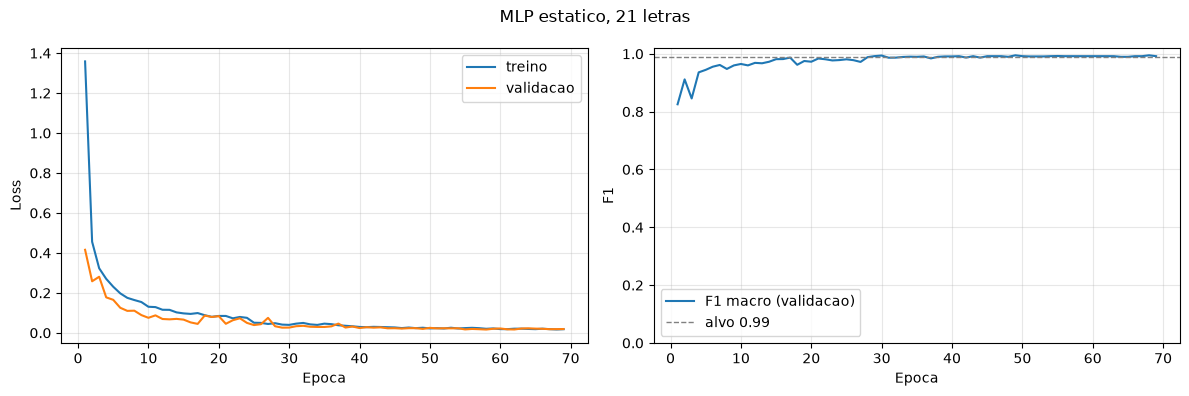

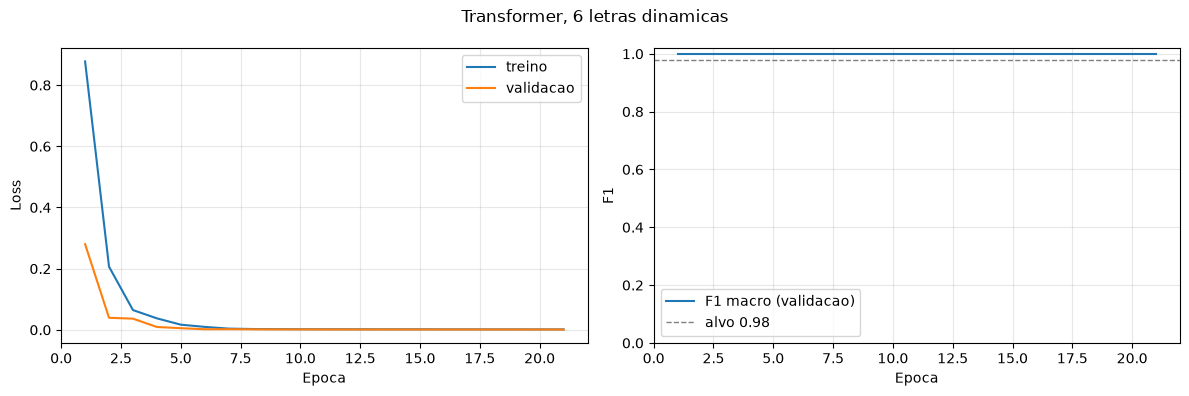

In [15]:
def curvas(log, titulo, alvo):
    hist = log["history"]
    ep = [h["epoch"] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ep, [h["train_loss"] for h in hist], label="treino")
    ax1.plot(ep, [h["val_loss"] for h in hist], label="validacao")
    ax1.set_xlabel("Epoca"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, [h["val_f1_macro"] for h in hist], label="F1 macro (validacao)")
    ax2.axhline(alvo, color="gray", ls="--", lw=1, label=f"alvo {alvo}")
    ax2.set_xlabel("Epoca"); ax2.set_ylabel("F1"); ax2.set_ylim(0, 1.02)
    ax2.legend(); ax2.grid(alpha=0.3)
    fig.suptitle(titulo)
    plt.tight_layout(); plt.show()

curvas(mlp_log, "MLP estatico, 21 letras", 0.99)
curvas(tf_log, "Transformer, 6 letras dinamicas", 0.98)


### 5.2 Matrizes de confusão

Recomputadas aqui sobre o mesmo split de validação do treino (mesma semente e mesma
estratificação), usando o melhor checkpoint de cada modelo.


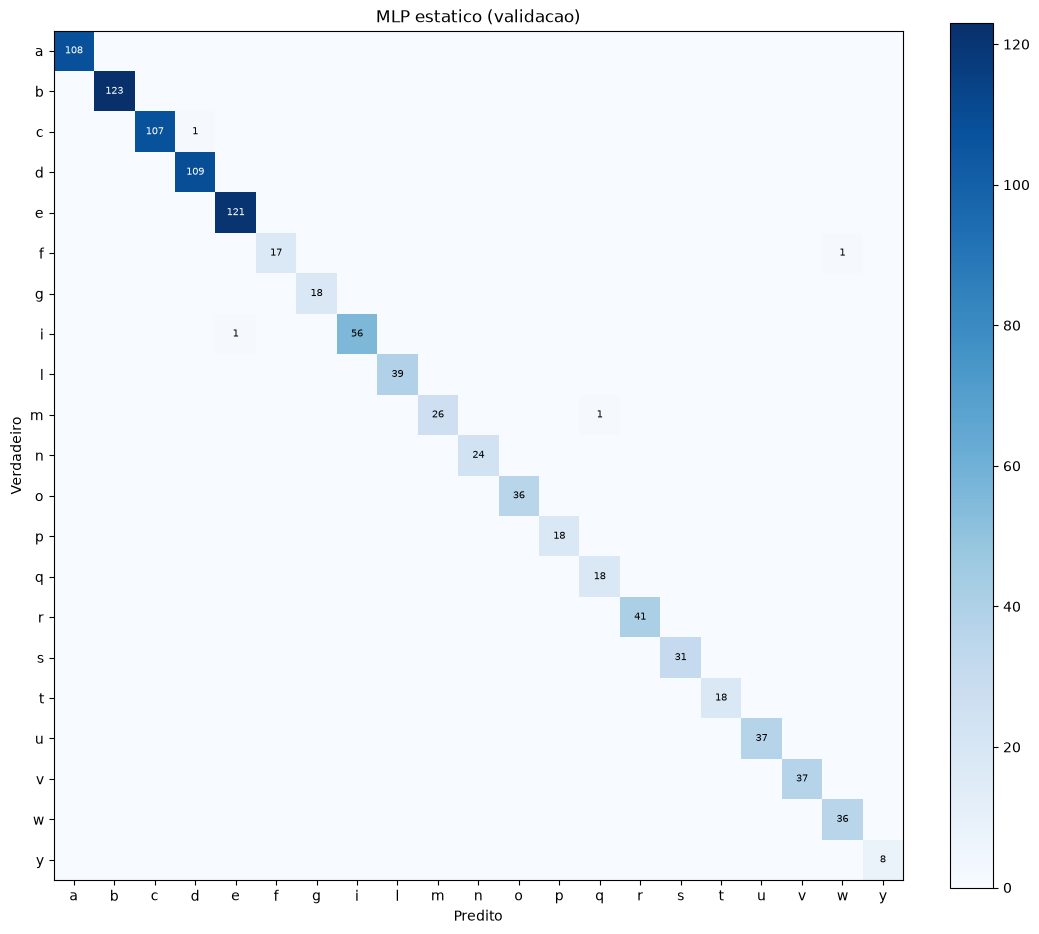

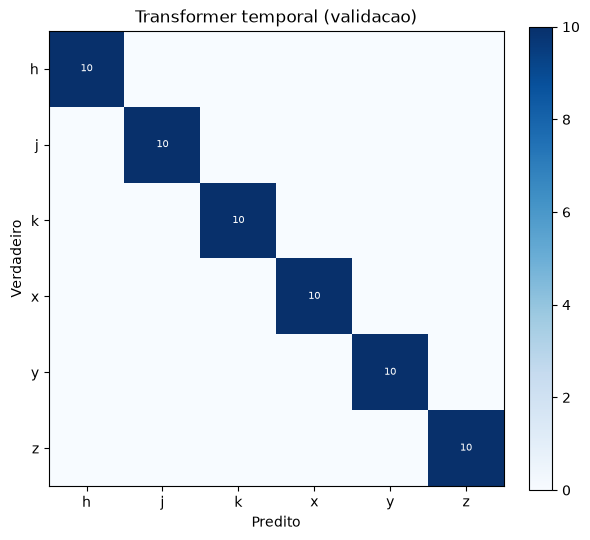

In [16]:
def matriz_confusao(model, roots, modo, label_map, titulo):
    roots = [Path(r) for r in roots]
    ds = LibrasDataset(roots, mode=modo, label_map=label_map, augment=False)
    base_targets = [lab for _, lab in ds.samples]
    _, val_base = train_test_split(list(range(len(ds.samples))),
                                   test_size=HPARAMS["val_ratio"],
                                   stratify=base_targets, random_state=SEED)
    loader = DataLoader(Subset(ds, val_base), batch_size=64, shuffle=False)
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            y_true.extend(y.numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())
    idx_to_label = {v: k for k, v in label_map.items()}
    names = [idx_to_label[i] for i in range(len(label_map))]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_map))))
    fig, ax = plt.subplots(figsize=(max(6, len(names) * 0.5),) * 2)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(names)), names)
    ax.set_yticks(range(len(names)), names)
    ax.set_xlabel("Predito"); ax.set_ylabel("Verdadeiro"); ax.set_title(titulo)
    limiar = cm.max() / 2
    for i in range(len(names)):
        for j in range(len(names)):
            if cm[i, j] > 0:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                        color="white" if cm[i, j] > limiar else "black")
    fig.colorbar(im, fraction=0.046)
    plt.tight_layout(); plt.show()

matriz_confusao(mlp_model, ROOTS_ESTATICO, "static", mlp_labels,
                "MLP estatico (validacao)")
matriz_confusao(tf_model, ROOTS_DINAMICO, "sequence", tf_labels,
                "Transformer temporal (validacao)")


**Leitura.** No MLP, os raros erros concentram-se em pares de configuração de mão
vizinha (por exemplo, m e n, u e v), uma ambiguidade real do alfabeto que a inferência
ao vivo mitiga com os guardrails temporais da seção 6. No Transformer, com 6 classes de
trajetórias bem distintas e 50 amostras por classe do mesmo domínio, a matriz tende à
diagonal perfeita, consistente com o F1 igual a 1.00 que as letras dinâmicas sustentaram
em todos os treinos do projeto, inclusive nos modelos maiores com vocabulário de
palavras.

### 5.3 A ablação: por que dois modelos

O resultado central do estudo:

1. **O baseline estático é estruturalmente cego ao movimento.** O MLP consome apenas o
   frame central da janela: para um "j" (um "i" que desenha um gancho), esse frame é
   indistinguível de um "i" parado. Nenhum aumento de capacidade resolve; é falta de
   informação na entrada, não de modelo.
2. **O modelo temporal resolve exatamente essa lacuna**, com F1 igual a 1.00 nas 6
   letras dinâmicas, confirmando a hipótese da seção 1.3.
3. **Especialização vence unificação em precisão.** Uma fase anterior do projeto treinou
   um único Transformer de 79 classes cobrindo letras e palavras: as letras estáticas
   caíram para F1 0.9839, contra 0.9947 do MLP especializado treinado nos mesmos dados.
   A configuração final privilegia a precisão: cada modelo opera no regime em que é
   superior, e a interface ao vivo faz o roteamento.


## 6. Inferência ao vivo

A aplicação final roda os dois modelos simultaneamente sobre a webcam, com alternância
por barra de espaço entre o modo LETRA (MLP) e o modo LETRA DINÂMICA (Transformer).
Predições por frame são convertidas em símbolos estáveis por guardrails temporais:

* **Modo LETRA**: o softmax é suavizado pela média das últimas 7 predições; o símbolo é
  aceito com consenso (as 7 concordam) e confiança mínima de 0.85. Isso elimina o
  flickering de predição.
* **Modo LETRA DINÂMICA**: um buffer circular de 30 frames é alimentado continuamente
  (trocar de modo já encontra a janela cheia); o Transformer prediz a cada 5 frames
  (cerca de 6 predições por segundo) apenas quando a mão está detectada há pelo menos
  10 frames; o símbolo é aceito com 2 predições consecutivas concordantes acima de 0.60.
* O detector roda em modo VIDEO (tracking entre frames) a 720p, decisivo para não perder
  a mão em movimento rápido.

A letra y tem variante estática e dinâmica no alfabeto e por isso existe nos dois
modelos: a tecla de modo decide qual variante responde. A célula abaixo contém a
aplicação completa; exige webcam e interface gráfica (não roda no Colab).


In [17]:
EXECUTAR_WEBCAM = False   # mude para True numa maquina com webcam

from collections import deque


class ReconhecedorEstatico:
    """MLP frame a frame com suavizacao de softmax e consenso temporal."""

    def __init__(self, model, idx_to_label, min_conf=0.85, stable_frames=7):
        self.model, self.idx_to_label, self.min_conf = model, idx_to_label, min_conf
        self.probs = deque(maxlen=stable_frames)
        self.preds = deque(maxlen=stable_frames)

    def reset(self):
        self.probs.clear(); self.preds.clear()

    def process(self, vec66):
        feat = expand_frame_for_model(vec66, augment=False)
        with torch.no_grad():
            p = torch.softmax(self.model(torch.from_numpy(feat).float()
                                         .unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
        self.probs.append(p)
        smoothed = np.mean(np.stack(self.probs), axis=0)
        top = int(np.argmax(smoothed)); prob = float(smoothed[top])
        self.preds.append(top)
        consenso = len(self.preds) == self.preds.maxlen and len(set(self.preds)) == 1
        if prob >= self.min_conf:
            return self.idx_to_label[top], prob, consenso
        return "?", prob, False


class ReconhecedorDinamico:
    """Transformer sobre janela deslizante de 30 frames com trigger e estabilidade."""

    def __init__(self, model, idx_to_label, min_conf=0.60, pred_every=5,
                 min_hand_frames=10):
        self.model, self.idx_to_label = model, idx_to_label
        self.min_conf, self.pred_every = min_conf, pred_every
        self.min_hand_frames = min_hand_frames
        self.buffer = deque(maxlen=FRAMES)
        self.frames_com_mao = 0
        self.frames_desde_pred = 0
        self._candidato = None
        self.ultima_letra, self.ultima_prob = None, 0.0

    def push(self, vec66):
        if vec66 is not None:
            self.buffer.append(vec66)
            self.frames_com_mao += 1
            self.frames_desde_pred += 1
        else:
            self.frames_com_mao = 0   # mao perdida: buffer fica, estabilidade recomeca

    def deve_predizer(self):
        return (len(self.buffer) == FRAMES
                and self.frames_com_mao >= self.min_hand_frames
                and self.frames_desde_pred >= self.pred_every)

    def predizer(self):
        seq = expand_sequence_for_model(np.stack(list(self.buffer)), augment=False)
        with torch.no_grad():
            p = torch.softmax(self.model(torch.from_numpy(seq).float()
                                         .unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
        self.frames_desde_pred = 0
        top = int(np.argmax(p)); prob = float(p[top])
        if prob < self.min_conf:
            self._candidato = None
            return "?", prob, False
        estavel = top == self._candidato
        self._candidato = top
        letra = self.idx_to_label[top]
        if estavel:
            self.ultima_letra, self.ultima_prob = letra, prob
        return letra, prob, estavel


def inferencia_ao_vivo():
    import cv2
    import mediapipe as mp
    estatico = ReconhecedorEstatico(mlp_model, {v: k for k, v in mlp_labels.items()})
    dinamico = ReconhecedorDinamico(tf_model, {v: k for k, v in tf_labels.items()})
    landmarker = criar_landmarker(modo_video=True)
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    modo, prev_wrist, t0 = "LETRA", None, time.monotonic()
    print("espaco alterna o modo, q sai")
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.flip(frame, 1)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                          data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        result = landmarker.detect_for_video(mp_img, int((time.monotonic() - t0) * 1000))
        vec = None
        if result.hand_landmarks:
            lms = result.hand_landmarks[0]
            h_px, w_px, _ = frame.shape
            for a, b in HAND_CONNECTIONS:
                pa = (int(lms[a].x * w_px), int(lms[a].y * h_px))
                pb = (int(lms[b].x * w_px), int(lms[b].y * h_px))
                cv2.line(frame, pa, pb, (0, 255, 0), 1)
            raw = extract_landmarks(lms)
            normalized, wrist_raw = normalize_landmarks(raw)
            if prev_wrist is None:
                prev_wrist = wrist_raw.copy()
            vec = build_feature_vector(normalized, wrist_raw, prev_wrist)
            prev_wrist = wrist_raw.copy()
        else:
            prev_wrist = None
            estatico.reset()
        dinamico.push(vec)   # buffer alimentado nos dois modos: janela sempre quente
        if modo == "LETRA" and vec is not None:
            letra, prob, estavel = estatico.process(vec)
            cor = (0, 255, 0) if estavel else (0, 255, 255)
            cv2.putText(frame, f"{letra.upper()} {prob*100:.0f}%", (10, 110),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, cor, 3)
        elif modo != "LETRA":
            if dinamico.deve_predizer():
                dinamico.predizer()
            if dinamico.ultima_letra:
                cv2.putText(frame, f"{dinamico.ultima_letra.upper()} "
                            f"{dinamico.ultima_prob*100:.0f}%", (10, 110),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        cv2.putText(frame, f"MODO: {modo}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 100, 100), 2)
        cv2.imshow("Libras", frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        if key == ord(" "):
            modo = "LETRA DINAMICA" if modo == "LETRA" else "LETRA"
            estatico.reset()
    cap.release(); cv2.destroyAllWindows(); landmarker.close()


if EXECUTAR_WEBCAM:
    inferencia_ao_vivo()
else:
    print("Aplicacao definida. Mude EXECUTAR_WEBCAM para True numa maquina com webcam.")


Aplicacao definida. Mude EXECUTAR_WEBCAM para True numa maquina com webcam.


A célula seguinte valida a aplicação sem webcam: carrega uma amostra real de cada
regime e confere a predição dos dois reconhecedores.


In [18]:
# Validacao sem webcam: uma amostra estatica e uma dinamica
amostra_estatica = sorted((DATA / "raw").glob("*/*.npy"))[0]
classe_estatica = amostra_estatica.parent.name
t = np.load(amostra_estatica)
feat = expand_frame_for_model(t[STATIC_FRAME_IDX], augment=False)
with torch.no_grad():
    p = torch.softmax(mlp_model(torch.from_numpy(feat).float().unsqueeze(0).to(DEVICE)),
                      dim=1)[0]
idx_to_label = {v: k for k, v in mlp_labels.items()}
print(f"estatica '{classe_estatica}' -> predito "
      f"'{idx_to_label[int(p.argmax())]}' ({p.max():.3f})")

amostra_dinamica = sorted((DATA / "luiz_split/dynamic/j").glob("*.npy"))[0]
seq = expand_sequence_for_model(np.load(amostra_dinamica).astype(np.float32), augment=False)
with torch.no_grad():
    p = torch.softmax(tf_model(torch.from_numpy(seq).float().unsqueeze(0).to(DEVICE)),
                      dim=1)[0]
idx_to_label = {v: k for k, v in tf_labels.items()}
print(f"dinamica 'j' -> predito '{idx_to_label[int(p.argmax())]}' ({p.max():.3f})")


estatica 'f' -> predito 'f' (1.000)
dinamica 'j' -> predito 'j' (0.889)


## 7. Conclusão

### 7.1 Síntese

A POC confirma a hipótese do estudo de ablação: **a natureza do sinal dita a
arquitetura**. Sobre um pipeline único de landmarks (MediaPipe, normalização, 86
features geométricas), um MLP de cerca de 60 mil parâmetros resolve as 21 letras
estáticas (F1 macro em torno de 0.99) e um Transformer encoder compacto resolve as 6
letras dinâmicas (F1 igual a 1.00), ambos treinados em CPU e servindo a cerca de 30 fps
numa webcam comum. A restrição do edital (nada de CNN sobre pixels) não foi um
obstáculo, e sim o que tornou o sistema leve o suficiente para tempo real sem GPU.

Metodologicamente, o trabalho valida três apostas: primeira, o isolamento geométrico,
em que features de landmarks normalizadas somadas a medidas invariantes a rotação
carregam toda a informação necessária do alfabeto; segunda, a augmentation no espaço de
landmarks com coerência temporal por sequência; terceira, dados do domínio alvo como o
único remédio efetivo para o deslocamento de domínio entre estúdio e webcam.

### 7.2 Limitações

* **Uma mão**: sinais bimanuais exigiriam dobrar o vetor de features e resolver
  atribuição esquerda-direita e padding de mão ausente.
* **Deslocamento de domínio residual**: usuários e câmeras muito diferentes das
  capturas de treino degradam o MLP; a mitigação conhecida é capturar amostras do novo
  domínio.
* **Vocabulário**: palavras ficaram fora do escopo final. A infraestrutura temporal
  (janela de 30 frames com Transformer) já as suporta, e os experimentos com o
  MINDS-Libras [5] chegaram a F1 0.85 em 20 palavras, mas com apenas 3 sinalizadores de
  estúdio o desempenho ao vivo não atinge o padrão do alfabeto.
* **Alternância manual** entre modos: o roteamento automático entre estático e dinâmico
  (aprendido a partir do delta do pulso) foi demonstrado na fase do modelo unificado,
  mas custou precisão.

### 7.3 Trabalhos futuros

1. Reintroduzir palavras com dados do domínio alvo (capturas próprias por classe).
2. Um roteador leve entre os modos (limiar sobre a energia do delta do pulso) para
   eliminar a tecla sem fundir os classificadores.
3. Suporte a duas mãos; soletração contínua com modelo de linguagem (autocorreção).
4. Quantização e exportação (ONNX) para navegador ou dispositivo móvel.

## 8. Referências

[1] F. Zhang, V. Bazarevsky, A. Vakunov, A. Tkachenka, G. Sung, C.-L. Chang,
M. Grundmann. MediaPipe Hands: On-device Real-time Hand Tracking. arXiv:2006.10214, 2020.

[2] A. Vaswani, N. Shazeer, N. Parmar, J. Uszkoreit, L. Jones, A. N. Gomez, L. Kaiser,
I. Polosukhin. Attention Is All You Need. NeurIPS, 2017.

[3] R. Xiong, Y. Yang, D. He, K. Zheng, S. Zheng, C. Xing, H. Zhang, Y. Lan, L. Wang,
T.-Y. Liu. On Layer Normalization in the Transformer Architecture. ICML, 2020.

[4] B. T. P. A. Andrade. Brazilian Sign Language Alphabet Dataset, 2019.

[5] T. M. Rezende, S. G. M. Almeida, F. G. Guimaraes. Development and validation of a
Brazilian sign language database for human gesture recognition. Neural Computing and
Applications, 2021.

[6] C. Shorten, T. M. Khoshgoftaar. A survey on Image Data Augmentation for Deep
Learning. Journal of Big Data, 2019.

[7] N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever, R. Salakhutdinov. Dropout:
A Simple Way to Prevent Neural Networks from Overfitting. JMLR, 2014.

[8] D. P. Kingma, J. Ba. Adam: A Method for Stochastic Optimization. ICLR, 2015.
